In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
lam = 2.0   # arrival rate (lambda)
mu = 3.0    # service rate (mu)
N = 100000  # number of packets

np.random.seed(42)

# -----------------------------
# Generate Random Variables
# -----------------------------
inter_arrivals = np.random.exponential(1/lam, N)
service_times = np.random.exponential(1/mu, N)

# Compute arrival times
arrival_times = np.cumsum(inter_arrivals)

# Simulate single server queue
start_service = np.zeros(N)
finish_service = np.zeros(N)

for i in range(N):
    if i == 0:
        start_service[i] = arrival_times[i]
    else:
        start_service[i] = max(arrival_times[i], finish_service[i-1])
    finish_service[i] = start_service[i] + service_times[i]

# Delay
delay = finish_service - arrival_times

print("Simulation complete.")
print("Mean Delay (Empirical):", np.mean(delay))
print("Theoretical Mean Delay:", 1/(mu-lam))


Simulation complete.
Mean Delay (Empirical): 1.0047353603390912
Theoretical Mean Delay: 1.0


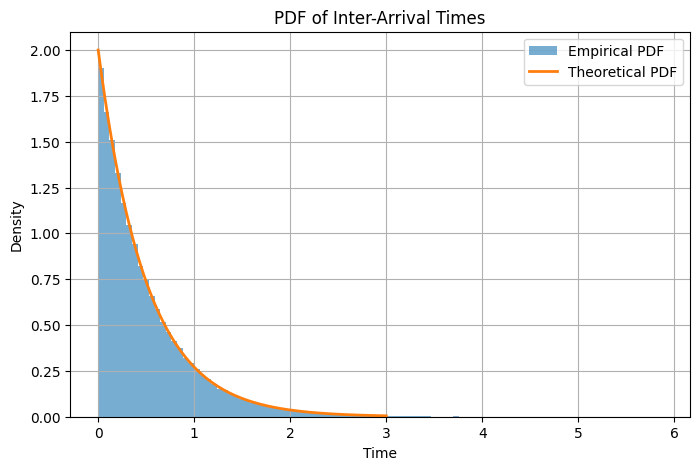

In [2]:
plt.figure(figsize=(8,5))
plt.hist(inter_arrivals, bins=100, density=True, alpha=0.6, label="Empirical PDF")

x = np.linspace(0, 3, 500)
plt.plot(x, lam*np.exp(-lam*x), linewidth=2, label="Theoretical PDF")

plt.title("PDF of Inter-Arrival Times")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


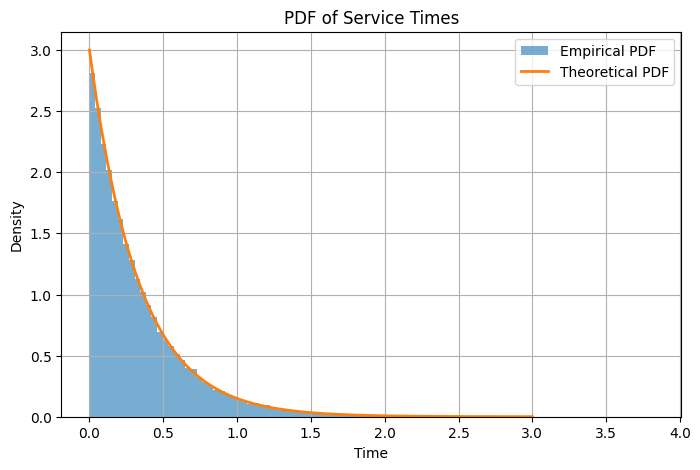

In [3]:
plt.figure(figsize=(8,5))
plt.hist(service_times, bins=100, density=True, alpha=0.6, label="Empirical PDF")

x = np.linspace(0, 3, 500)
plt.plot(x, mu*np.exp(-mu*x), linewidth=2, label="Theoretical PDF")

plt.title("PDF of Service Times")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


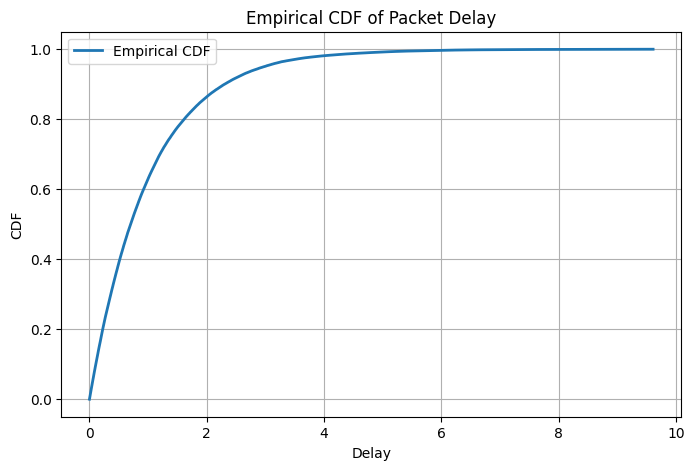

In [4]:
sorted_delay = np.sort(delay)
cdf = np.arange(1, N+1) / N

plt.figure(figsize=(8,5))
plt.plot(sorted_delay, cdf, linewidth=2, label="Empirical CDF")

plt.title("Empirical CDF of Packet Delay")
plt.xlabel("Delay")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.show()


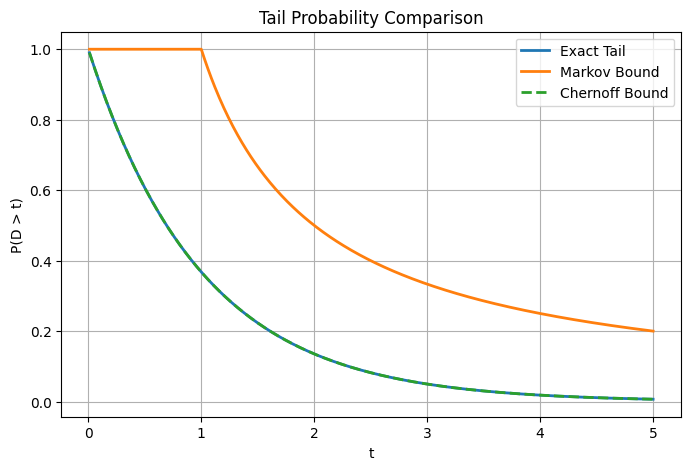

In [5]:
t_vals = np.linspace(0.01, 5, 500)

# Exact tail for M/M/1
exact_tail = np.exp(-(mu - lam) * t_vals)

# Markov bound
mean_delay = 1/(mu - lam)
markov_bound = np.minimum(mean_delay / t_vals, 1)

# Chernoff bound (same exponential decay here)
chernoff_bound = np.exp(-(mu - lam) * t_vals)

plt.figure(figsize=(8,5))
plt.plot(t_vals, exact_tail, linewidth=2, label="Exact Tail")
plt.plot(t_vals, markov_bound, linewidth=2, label="Markov Bound")
plt.plot(t_vals, chernoff_bound, linestyle="--", linewidth=2, label="Chernoff Bound")

plt.title("Tail Probability Comparison")
plt.xlabel("t")
plt.ylabel("P(D > t)")
plt.legend()
plt.grid(True)
plt.show()
